## Poin-poin Assignment
0. Import Dataset pilih salah satu :
- https://www.kaggle.com/datasets/muhammadshahidazeem/customer-churn-dataset
- https://www.kaggle.com/datasets/gauravtopre/bank-customer-churn-dataset
- https://www.kaggle.com/datasets/saurabhbadole/bank-customer-churn-prediction-dataset
1. Jawablah poin-poin assignment yang tertera

## Import Libraries

In [ ]:
# load pandas untuk data wrangling
import pandas as pd
# load numpy untuk manipulasi vektor
import numpy as np
# load matplotlib untuk visualisasi data
import matplotlib.pyplot as plt
# load seaborn untuk visualisasi data
import seaborn as sns

# load metrics object dari sklearn
from sklearn import metrics
# load train-test data splitter
from sklearn.model_selection import train_test_split
# Import Decision Tree classifier (DT)
from sklearn.tree import DecisionTreeClassifier
# Import Logistic Regression classifier
from sklearn.linear_model import LogisticRegression
# load SVM classifier model
from sklearn.svm import SVC
# load KNN classifier model
from sklearn.neighbors import KNeighborsClassifier

#import for metrics
from sklearn.metrics import precision_score, \
    recall_score, confusion_matrix, classification_report, \
    accuracy_score, f1_score, roc_auc_score
from sklearn.metrics import confusion_matrix,ConfusionMatrixDisplay,classification_report,accuracy_score


# Set the maximum number of columns and rows to display to a large number
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', None)

%matplotlib inline

## Load Dataset From Kaggle

In [ ]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("muhammadshahidazeem/customer-churn-dataset")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'customer-churn-dataset' dataset.
Path to dataset files: /kaggle/input/customer-churn-dataset


In [ ]:
import os

# List files dalam dictionary
files = os.listdir(path)
print("Files in the dataset directory:", files)

Files in the dataset directory: ['customer_churn_dataset-testing-master.csv', 'customer_churn_dataset-training-master.csv']


In [ ]:
# mengasumsikan nama file
file_path = f"{path}/customer_churn_dataset-training-master.csv"
df = pd.read_csv(file_path)

# Display the first 5 rows dari dataframe
display(df.head())

,CustomerID,Age,Gender,Tenure,Usage Frequency,Support Calls,Payment Delay,Subscription Type,Contract Length,Total Spend,Last Interaction,Churn
0,2.0,30.0,Female,39.0,14.0,5.0,18.0,Standard,Annual,932.0,17.0,1.0
1,3.0,65.0,Female,49.0,1.0,10.0,8.0,Basic,Monthly,557.0,6.0,1.0
2,4.0,55.0,Female,14.0,4.0,6.0,18.0,Basic,Quarterly,185.0,3.0,1.0
3,5.0,58.0,Male,38.0,21.0,7.0,7.0,Standard,Monthly,396.0,29.0,1.0
4,6.0,23.0,Male,32.0,20.0,5.0,8.0,Basic,Monthly,617.0,20.0,1.0


## Memeriksa Struktur Data

In [ ]:
df.sample(2)

,CustomerID,Age,Gender,Tenure,Usage Frequency,Support Calls,Payment Delay,Subscription Type,Contract Length,Total Spend,Last Interaction,Churn
251807,258911.0,59.0,Male,29.0,23.0,5.0,17.0,Basic,Quarterly,608.64,15.0,1.0
401942,409057.0,22.0,Male,43.0,27.0,1.0,0.0,Premium,Annual,621.97,5.0,0.0


In [ ]:
# Melihat ringkasan data
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 440833 entries, 0 to 440832
Data columns (total 12 columns):
 #   Column             Non-Null Count   Dtype  
---  ------             --------------   -----  
 0   CustomerID         440832 non-null  float64
 1   Age                440832 non-null  float64
 2   Gender             440832 non-null  object 
 3   Tenure             440832 non-null  float64
 4   Usage Frequency    440832 non-null  float64
 5   Support Calls      440832 non-null  float64
 6   Payment Delay      440832 non-null  float64
 7   Subscription Type  440832 non-null  object 
 8   Contract Length    440832 non-null  object 
 9   Total Spend        440832 non-null  float64
 10  Last Interaction   440832 non-null  float64
 11  Churn              440832 non-null  float64
dtypes: float64(9), object(3)
memory usage: 40.4+ MB


Keterangan Data:
- CustomerID: Nomor identitas unik untuk setiap pelanggan. Berfungsi sebagai ID agar data tidak bercampur.
- Age: Usia pelanggan (dalam tahun).
- Gender: Jenis kelamin pelanggan Male atau Female.
- Tenure: Lama pelanggan telah berlangganan layanan.
- Usage Frequency: Seberapa sering pelanggan menggunakan layanan dalam periode tertentu.
- Support Calls: Jumlah panggilan atau interaksi pelanggan dengan layanan pelanggan (customer support)
- Payment Delay: Rata-rata keterlambatan pembayaran pelanggan (dalam hari).
- Subscription Type: Jenis paket langganan pelanggan, misalnya Basic, Standard, atau Premium.
- Contract Length: Durasi kontrak langganan pelanggan, seperti Monthly (bulanan), Quarterly (triwulan), atau Annual (tahunan).
- Total Spend: Total uang yang telah dikeluarkan pelanggan selama berlangganan (biasanya dalam satuan mata uang tertentu).
- Last Interaction: Jumlah hari sejak interaksi terakhir pelanggan dengan perusahaan. Nilai besar bisa menunjukkan pelanggan mulai pasif.
- Churn
Variabel target — menunjukkan apakah pelanggan berhenti (1) atau tetap berlangganan (0).

In [ ]:
# Menampilkan statistika data numerik
df.describe()

,CustomerID,Age,Tenure,Usage Frequency,Support Calls,Payment Delay,Total Spend,Last Interaction,Churn
count,440832.000000,440832.000000,440832.000000,440832.000000,440832.000000,440832.000000,440832.000000,440832.000000,440832.000000
mean,225398.667955,39.373153,31.256336,15.807494,3.604437,12.965722,631.616223,14.480868,0.567107
std,129531.918550,12.442369,17.255727,8.586242,3.070218,8.258063,240.803001,8.596208,0.495477
min,2.000000,18.000000,1.000000,1.000000,0.000000,0.000000,100.000000,1.000000,0.000000
25%,113621.750000,29.000000,16.000000,9.000000,1.000000,6.000000,480.000000,7.000000,0.000000
50%,226125.500000,39.000000,32.000000,16.000000,3.000000,12.000000,661.000000,14.000000,1.000000
75%,337739.250000,48.000000,46.000000,23.000000,6.000000,19.000000,830.000000,22.000000,1.000000
max,449999.000000,65.000000,60.000000,30.000000,10.000000,30.000000,1000.000000,30.000000,1.000000


In [ ]:
# Menampilkan statistika data kategorikal
df.describe(include='object')

,Gender,Subscription Type,Contract Length
count,440832,440832,440832
unique,2,3,3
top,Male,Standard,Annual
freq,250252,149128,177198


## Data Cleaning

### Duplicate Check

In [ ]:
df.duplicated().sum()

np.int64(0)

### Missing Value Check

In [ ]:
df.isnull().sum()

,0
CustomerID,1
Age,1
Gender,1
Tenure,1
Usage Frequency,1
Support Calls,1
Payment Delay,1
Subscription Type,1
Contract Length,1
Total Spend,1


In [ ]:
# Drop baris yang mengandung nilai missing
df.dropna(inplace=True)

# Menampilkan kembali kolom
display(df.isnull().sum())

,0
CustomerID,0
Age,0
Gender,0
Tenure,0
Usage Frequency,0
Support Calls,0
Payment Delay,0
Subscription Type,0
Contract Length,0
Total Spend,0


## Exploratory Data Analysis
- Lakukan analisa pada EDA menggunakan visualisasi di tiap variabel :
1. Kategorikal vs Churn Label
2. Numerik vs Churn Label
3. Anda wajib menuliskan insight, sebagai langkah untuk pencegahan churn dalam strategi marketing

In [ ]:
target_column = 'Churn'

ordinal_columns = [
    'Subscription Type',
    'Contract Length',
]

nominal_columns = 'Gender'

category_columns = ordinal_columns + [nominal_columns]

numeric_columns = [
    'Age',
    'Tenure',
    'Usage Frequency',
    'Support Calls',
    'Payment Delay',
    'Total Spend',
    'Last Interaction',
]

In [ ]:
# Traget
df['Churn'].value_counts()

,count
Churn,
1.0,249999
0.0,190833


### Kategorikal vs Churn label

In [ ]:
from scipy.stats import chi2_contingency
from scipy.stats.contingency import association

# Membuat dataFrame untuk hasil analisis
df_dist_cat = pd.DataFrame()
for column in category_columns: # melakukan loop untuk setiap kolom kategori
  df_temp = df.pivot_table( # membuat pivot table
      index = column,
      columns = 'Churn',
      values = 'CustomerID',
      aggfunc = 'nunique', # nilai customer id dihitung unik
  ).fillna(0).astype(int) # Fill NaN with 0 and then convert to integers

  # Melakukan uji chi-square kontingensi untuk mengetahui signifikan asosiasi kolom kategori dengan churn
  res = chi2_contingency(df_temp)
  coef = round(association(df_temp, method='cramer'), 2) # menghitung ukuran asosiasi cramer


  index_tuples = [(column, x) for x in df_temp.index] #
  df_temp.index = pd.MultiIndex.from_tuples(
      index_tuples,
      names=['column', 'value'],
  )
 # menambahkan kolom churn_proba untuk menunjukkan probabilitas churn per nilai kategori
  df_temp['churn_proba'] = df_temp[1.0] / (df_temp[0.0] + df_temp[1.0])
  df_temp['pvalue'] = ('' if res.pvalue > 0.05 else '<0.05')
  df_temp['coef'] = coef

  df_dist_cat = pd.concat([df_dist_cat, df_temp])

df_dist_cat

Churn                           0.0     1.0  churn_proba pvalue  coef
column            value                                              
Subscription Type Basic       59816   83210     0.581782  <0.05  0.02
                  Premium     65505   83173     0.559417  <0.05  0.02
                  Standard    65512   83616     0.560700  <0.05  0.02
Contract Length   Annual      95552   81646     0.460761  <0.05  0.43
                  Monthly         0   87104     1.000000  <0.05  0.43
                  Quarterly   95281   81249     0.460256  <0.05  0.43
Gender            Female      63522  127058     0.666691  <0.05  0.18
                  Male       127311  122941     0.491269  <0.05  0.18

Insight:

- Jenis Langganan (Subscription Type): Pada value basic, premium, dan standard probabilitas churnya sekitar 0.56-0.58 yang berarti pelanggan memiliki kemungkinan churn yang mirip. Untuk nilai koefisiennya kecil (0.02) sehingnga tipe langganan tidak terlalu berpengaruh terhadap churn.
- Durasi Kontrak (Contract Length): Pada pelanngan dengan kontak bulanan memiliki churn_proba 1.0 yang berarti semua pelanggan yang berlangganan bulanan beresiko tinggi untuk churn. Untuk kontak tahunan dan kuartil memiliki churn_proba (0.46) yang berarti pelanggan lebih panjang berlangganan dan cenderung lebih loyal. Dan untuk koefisiennya memiliki nilai yang besar (0.43), yang berarti durasi kontrak mempengaruhi pelanggan yang churn.
- Jenis Kelamin (Gender): Pada female memiliki nilai churn_proba yang lebih tinggi dari male yaitu (0.66) sedangkan male (0.49) yang berarti pelanggan perempuan lebih beresiko untuk churn dibandingkan laki-laki dan untuk nilai koefisiennya sedang (0.18) yang berarti gender cukup mempengaruhi churn.

Strategi marketing pencegahan churn:

- Prioritaskan Durasi Kontrak: Strategi yang bisa dilakukan yaitu dengan memberikan diskon atau bonus bagi pelanggan yang bersedia beralih dari kontrak bulanan ke triwulanan atau tahunan. Dengan promosikan stabilitas dan keuntungan jangka panjang dari kontrak yang lebih lama.
- Program loyalitas: Bisa dengan membuat program loyalitas yang memberikan penghargaan kepada pelanggan berdasarkan durasi berlangganan atau penggunaan layanan. Agar dapat mendorong pelanggan untuk tetap berlangganan lebih lama.
- Investigasi Jenis Langganan: Lakukan investigasi lebih lanjut terhadap jenis langganan 'Basic' untuk memahami apakah ada masalah atau fitur yang hilang yang berkontribusi pada probabilitas churn yang sedikit lebih tinggi dibandingkan dengan jenis langganan lainnya.
- Fokus kepada produk yang dibutuhkan berdasarkan jender: dikarenakan pelanggan perempuan rawan churn tawarkan produk yang memang dibutuhkan oleh perempuan agar mereka tidak churn.

Visualisasi

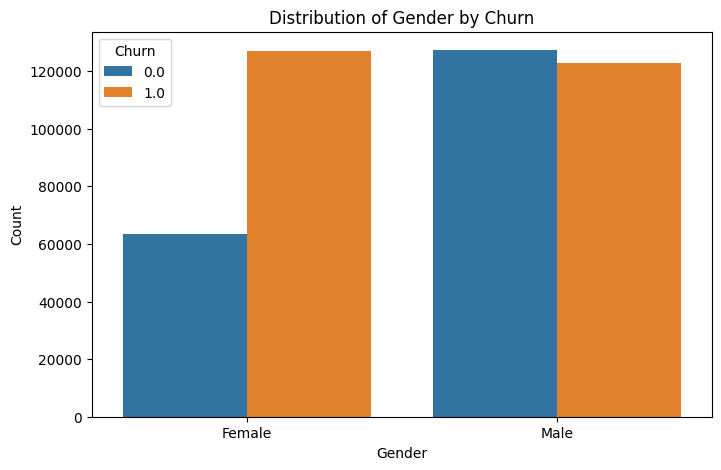

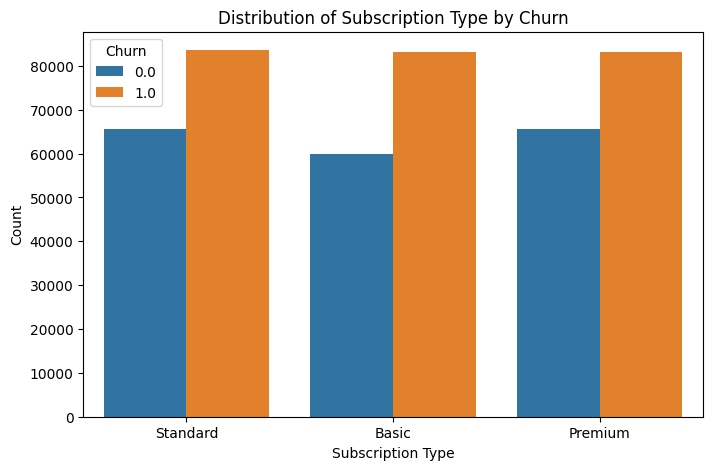

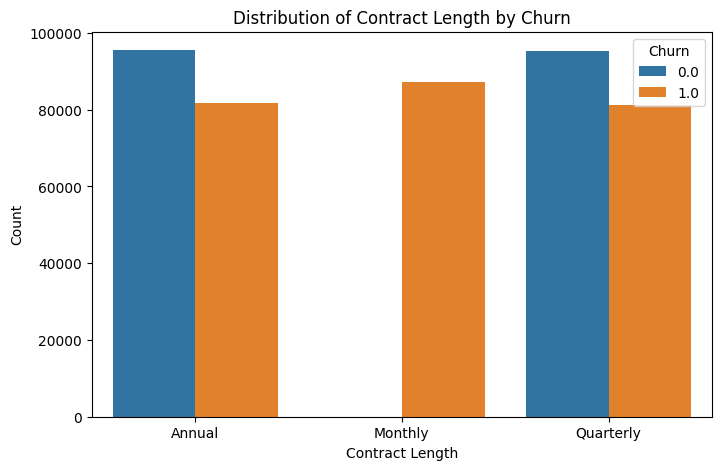

In [ ]:
categorical_cols = df.select_dtypes(include='object').columns

for col in categorical_cols:
    plt.figure(figsize=(8, 5))
    sns.countplot(data=df, x=col, hue='Churn')
    plt.title(f'Distribution of {col} by Churn')
    plt.xlabel(col)
    plt.ylabel('Count')
    plt.show()

### Numerik vs Churn Label

In [ ]:
numerical_cols = df.select_dtypes(include=np.number).columns
numerical_cols



Index(['CustomerID', 'Age', 'Tenure', 'Usage Frequency', 'Support Calls',
       'Payment Delay', 'Total Spend', 'Last Interaction', 'Churn'],
      dtype='object')

In [ ]:
from scipy.stats import ttest_ind

def show_distribution_numerik(column):
  res = ttest_ind(
      df[df['Churn'] == 1.0][column],
      df[df['Churn'] == 0.0][column],
      equal_var=False,
      alternative='two-sided',
  )
  print('p-value: {0:2f}'.format(res.pvalue))

  HEX_RED = '#FF0000'
  HEX_BLUE = '#0000FF'

  sns.violinplot(
      data=df,
      hue='Churn',
      split=True,
      inner='quartile',
      x=column,
      gap=0.1,
      palette={1.0: HEX_RED, 0.0: HEX_BLUE},
  )

p-value: 0.000000


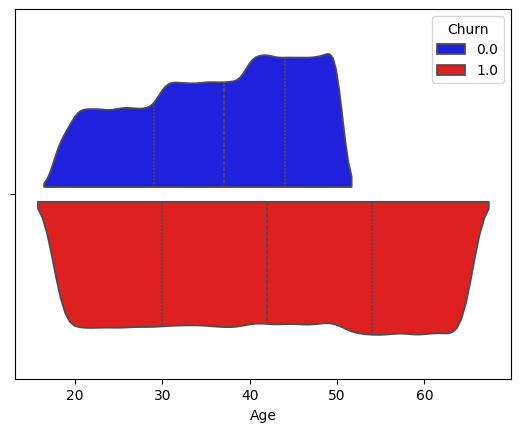

In [ ]:
# violin plot
show_distribution_numerik('Age')


p-value: 0.000000


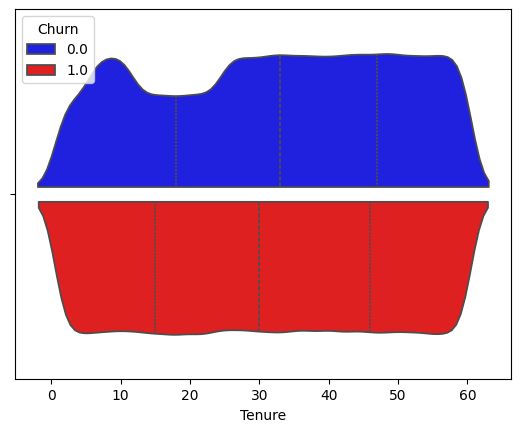

In [ ]:
show_distribution_numerik('Tenure')

p-value: 0.000000


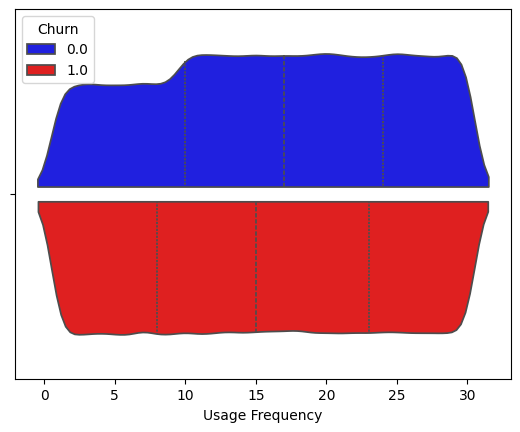

In [ ]:
show_distribution_numerik('Usage Frequency')

p-value: 0.000000


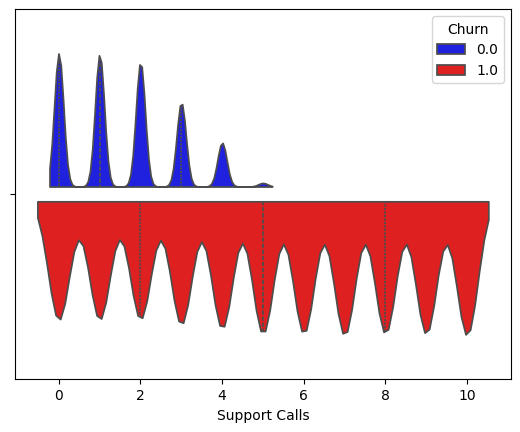

In [ ]:
show_distribution_numerik('Support Calls')

p-value: 0.000000


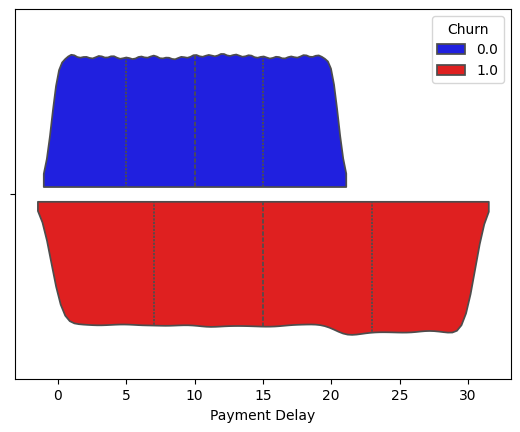

In [ ]:
show_distribution_numerik('Payment Delay')

p-value: 0.000000


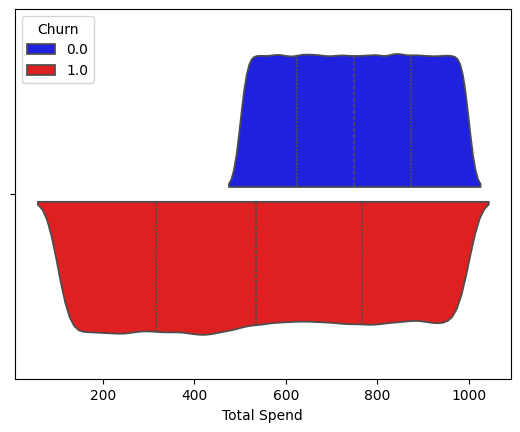

In [ ]:
show_distribution_numerik('Total Spend')

p-value: 0.000000


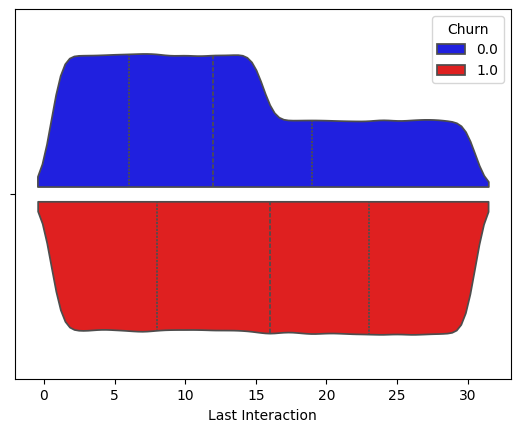

In [ ]:
show_distribution_numerik('Last Interaction')

Insight:

- Age : Distribusi churn berdasarkan usia terlihat bahwa pelanggan yang churn memiliki rentang usia yang lebih luas.
- Tenure : Pelanggan yang churn cenderung memiliki masa berlangganan (tenure) yang lebih pendek dibandingkan dengan pelanggan yang tidak churn. Yang  menunjukkan bahwa pelanggan baru atau yang belum lama berlangganan lebih berisiko untuk churn.
- Usage Frequency: Pelanggan yang churn memiliki frekuensi penggunaan layanan yang lebih rendah. Damapat diidentifikasi bahwa pelanggan yang kurang aktif lebih mungkin untuk berhenti berlangganan.
- Support Calls: Pelanggan yang churn cenderung melakukan lebih banyak panggilan dukungan. Menunjukkan bahwa pengalaman negatif dengan layanan pelanggan atau masalah teknis yang tidak terselesaikan dapat menjadi pendorong churn.
- Payment Delay: Pelanggan yang churn memiliki rata-rata keterlambatan pembayaran yang lebih tinggi. Indikator kesulitan finansial atau ketidakpuasan dengan layanan.
- Total Spend: Pelanggan yang churn cenderung memiliki total pengeluaran yang lebih rendah. Mungkin karena pengeluaran lebih rendah sehingga pelanggan tidak terlalu menikmati produk yang ditawarkan perusahaan.
- Last Interaction: Pelanggan yang churn memiliki jumlah hari yang lebih banyak sejak interaksi terakhir mereka. Menunjukkan bahwa pelanggan yang pasif atau tidak terlibat dengan perusahaan berisiko lebih tinggi untuk churn.

**Strategi Pencegahan Churn Berdasarkan Insight Numerik:**

*   **Fokus pada pelanggan baru:** Berikan program orientasi yang kuat dan dukungan ekstra untuk pelanggan baru selama masa berlangganan awal mereka. Tawarkan insentif atau bonus bagi pelanggan yang memperpanjang masa berlangganan mereka setelah periode awal.
*   **Dorong peningkatan penggunaan layanan:** Kirimkan notifikasi yang relevan dan personalisasi untuk mengingatkan pelanggan tentang manfaat layanan dan fitur-fitur baru. Sediakan tutorial atau panduan penggunaan untuk membantu pelanggan memanfaatkan layanan secara maksimal.
*   **Tingkatkan kualitas layanan pelanggan:** Pastikan tim dukungan pelanggan responsif, membantu, dan mampu menyelesaikan masalah dengan cepat dan efisien. Pertimbangkan untuk menyediakan berbagai saluran dukungan (telepon, email, chat) untuk memudahkan pelanggan menghubungi.
*   **Tawarkan opsi pembayaran yang fleksibel:** Sediakan berbagai metode pembayaran dan pertimbangkan program bantuan atau penyesuaian pembayaran bagi pelanggan yang mengalami kesulitan finansial.
*   **Berikan insentif untuk peningkatan langganan:** Tawarkan diskon atau bonus bagi pelanggan yang bersedia mengupgrade jenis langganan mereka. Sorot manfaat dan nilai tambah dari paket langganan yang lebih tinggi.
*   **Jaga pelanggan tetap terlibat:** Lakukan komunikasi proaktif dan personalisasi dengan pelanggan. Kirimkan email atau pesan yang berisi tips, informasi relevan, penawaran eksklusif, atau ucapan terima kasih untuk menjaga hubungan baik dan meningkatkan loyalitas.

## Assignment Feature Engineering
1. Perhatikan splitting
2. Serta beri alasan anda dalam melakukan proses feature engineering di setiap prosesnya

### Split Data

In [ ]:
# Pisahkan fitur (X) dan target (y)
X = df.drop('Churn', axis=1)
y = df['Churn']

# Bagi data menjadi training dan testing set
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print("Ukuran X_train:", X_train.shape)
print("Ukuran X_test:", X_test.shape)
print("Ukuran y_train:", y_train.shape)
print("Ukuran y_test:", y_test.shape)

Ukuran X_train: (352665, 11)
Ukuran X_test: (88167, 11)
Ukuran y_train: (352665,)
Ukuran y_test: (88167,)


In [ ]:
# Drop column customer id pada data train dan test
X_train = X_train.drop('CustomerID', axis=1)
X_test = X_test.drop('CustomerID', axis=1)

In [ ]:
# menampilkan categorical columns dari training data
categorical_cols = X_train.select_dtypes(include='object').columns

print("Categorical columns and their unique values and counts:")
for col in categorical_cols:
    print(f"\nColumn: {col}")
    display(X_train[col].value_counts())


Categorical columns and their unique values and counts:

Column: Gender


,count
Gender,
Male,200314
Female,152351



Column: Subscription Type


,count
Subscription Type,
Standard,119309
Premium,118824
Basic,114532



Column: Contract Length


,count
Contract Length,
Annual,141539
Quarterly,141288
Monthly,69838


### Encoding

In [ ]:
# Label Encoding
# Menentukan mapping untuk kolom biner
binary_mapping = {
    'Gender': {'Male': 1, 'Female': 0},
}

# Menerappkan mapping untuk X_train dan X_test
X_train = X_train.replace(binary_mapping)
X_test = X_test.replace(binary_mapping)

print("X_train after binary encoding:")
display(X_train.head())

print("\nX_test after binary encoding:")
display(X_test.head())

X_train after binary encoding:


/tmp/ipython-input-1803911702.py:8: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  X_train = X_train.replace(binary_mapping)
/tmp/ipython-input-1803911702.py:9: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  X_test = X_test.replace(binary_mapping)


,Age,Gender,Tenure,Usage Frequency,Support Calls,Payment Delay,Subscription Type,Contract Length,Total Spend,Last Interaction
318331,42.0,1,46.0,30.0,3.0,4.0,Standard,Annual,945.08,8.0
429062,33.0,0,43.0,17.0,1.0,15.0,Standard,Annual,987.79,12.0
60074,26.0,0,13.0,30.0,4.0,12.0,Premium,Quarterly,800.00,5.0
12759,29.0,0,9.0,23.0,10.0,24.0,Basic,Quarterly,119.00,19.0
357321,38.0,1,10.0,20.0,0.0,0.0,Basic,Annual,678.97,18.0



X_test after binary encoding:


,Age,Gender,Tenure,Usage Frequency,Support Calls,Payment Delay,Subscription Type,Contract Length,Total Spend,Last Interaction
30086,62.0,0,49.0,20.0,0.0,19.0,Basic,Monthly,175.00,22.0
368225,29.0,1,32.0,27.0,2.0,2.0,Standard,Quarterly,733.00,25.0
146939,40.0,0,39.0,16.0,8.0,0.0,Basic,Quarterly,542.00,3.0
368276,23.0,0,13.0,28.0,0.0,11.0,Basic,Quarterly,951.67,1.0
153765,18.0,1,10.0,15.0,3.0,15.0,Standard,Quarterly,970.00,17.0


In [ ]:
# One-Hot Encoding
# Menerapkan One-Hot Encoding untuk 'Contract' dan 'PaymentMethod' columns
X_train = pd.get_dummies(X_train, columns=['Subscription Type', 'Contract Length'], dtype=int)
X_test = pd.get_dummies(X_test, columns=['Subscription Type', 'Contract Length'], dtype=int)

print("X_train after One-Hot Encoding:")
display(X_train.head())

print("\nX_test after One-Hot Encoding:")
display(X_test.head())

X_train after One-Hot Encoding:


,Age,Gender,Tenure,Usage Frequency,Support Calls,Payment Delay,Total Spend,Last Interaction,Subscription Type_Basic,Subscription Type_Premium,Subscription Type_Standard,Contract Length_Annual,Contract Length_Monthly,Contract Length_Quarterly
318331,42.0,1,46.0,30.0,3.0,4.0,945.08,8.0,0,0,1,1,0,0
429062,33.0,0,43.0,17.0,1.0,15.0,987.79,12.0,0,0,1,1,0,0
60074,26.0,0,13.0,30.0,4.0,12.0,800.00,5.0,0,1,0,0,0,1
12759,29.0,0,9.0,23.0,10.0,24.0,119.00,19.0,1,0,0,0,0,1
357321,38.0,1,10.0,20.0,0.0,0.0,678.97,18.0,1,0,0,1,0,0



X_test after One-Hot Encoding:


,Age,Gender,Tenure,Usage Frequency,Support Calls,Payment Delay,Total Spend,Last Interaction,Subscription Type_Basic,Subscription Type_Premium,Subscription Type_Standard,Contract Length_Annual,Contract Length_Monthly,Contract Length_Quarterly
30086,62.0,0,49.0,20.0,0.0,19.0,175.00,22.0,1,0,0,0,1,0
368225,29.0,1,32.0,27.0,2.0,2.0,733.00,25.0,0,0,1,0,0,1
146939,40.0,0,39.0,16.0,8.0,0.0,542.00,3.0,1,0,0,0,0,1
368276,23.0,0,13.0,28.0,0.0,11.0,951.67,1.0,1,0,0,0,0,1
153765,18.0,1,10.0,15.0,3.0,15.0,970.00,17.0,0,0,1,0,0,1


In [ ]:
# Scalling
from sklearn.preprocessing import StandardScaler

# Identifikasi kolom numerik
# Memilih kembali kolom numerik dari df asli dan menghapus CustomerID dan Churn
numerical_cols = df.select_dtypes(include=np.number).columns.tolist()
numerical_cols.remove('CustomerID')
numerical_cols.remove('Churn')


# Inisialisasi StandardScaler
scaler = StandardScaler()

# Terapkan scaling pada data training
X_train[numerical_cols] = scaler.fit_transform(X_train[numerical_cols])

# Terapkan scaling pada data testing (menggunakan scaler yang sama yang fit pada data training)
X_test[numerical_cols] = scaler.transform(X_test[numerical_cols])

print("X_train after scaling:")
display(X_train.head())

print("\nX_test after scaling:")
display(X_test.head())

X_train after scaling:


,Age,Gender,Tenure,Usage Frequency,Support Calls,Payment Delay,Total Spend,Last Interaction,Subscription Type_Basic,Subscription Type_Premium,Subscription Type_Standard,Contract Length_Annual,Contract Length_Monthly,Contract Length_Quarterly
318331,0.210377,1,0.855271,1.651238,-0.197156,-1.085320,1.300956,-0.753449,0,0,1,1,0,0
429062,-0.512784,0,0.681455,0.137056,-0.848223,0.246158,1.478368,-0.288211,0,0,1,1,0,0
60074,-1.075242,0,-1.056712,1.651238,0.128377,-0.116972,0.698312,-1.102379,0,1,0,0,0,1
12759,-0.834189,0,-1.288467,0.835909,2.081578,1.335549,-2.130477,0.525957,1,0,0,0,0,1
357321,-0.111028,1,-1.230528,0.486483,-1.173756,-1.569494,0.195568,0.409648,1,0,0,1,0,0



X_test after scaling:


,Age,Gender,Tenure,Usage Frequency,Support Calls,Payment Delay,Total Spend,Last Interaction,Subscription Type_Basic,Subscription Type_Premium,Subscription Type_Standard,Contract Length_Annual,Contract Length_Monthly,Contract Length_Quarterly
30086,1.817400,0,1.029088,0.486483,-1.173756,0.730332,-1.897860,0.874887,1,0,0,0,1,0
368225,-0.834189,1,0.044127,1.301811,-0.522689,-1.327407,0.420002,1.223816,0,0,1,0,0,1
146939,0.049674,0,0.449699,0.020581,1.430511,-1.569494,-0.373388,-1.334998,1,0,0,0,0,1
368276,-1.316296,0,-1.056712,1.418287,-1.173756,-0.238016,1.328330,-1.567617,1,0,0,0,0,1
153765,-1.718052,1,-1.230528,-0.095895,-0.197156,0.246158,1.404470,0.293338,0,0,1,0,0,1


In [ ]:
# SMOTE
from imblearn.over_sampling import SMOTE

# Inisialisasi SMOTE
smote = SMOTE(random_state=42)

# Terapkan SMOTE hanya pada data training
X_train_smote, y_train_smote = smote.fit_resample(X_train, y_train)

print("Ukuran X_train setelah SMOTE:", X_train_smote.shape)
print("Ukuran y_train setelah SMOTE:", y_train_smote.shape)
print("\nDistribusi kelas setelah SMOTE:")
display(y_train_smote.value_counts())

Ukuran X_train setelah SMOTE: (399998, 14)
Ukuran y_train setelah SMOTE: (399998,)

Distribusi kelas setelah SMOTE:


,count
Churn,
0.0,199999
1.0,199999


Tahapan:
1. Split Data (Pembagian Data Menjadi Training dan Testing):

- Alasan: Untuk mengevaluasi kinerja model secara objektif. Data training (X_train, y_train) digunakan untuk melatih model, sementara data testing (X_test, y_test) digunakan untuk menguji seberapa baik model dapat digeneralisasi ke data yang belum pernah dilihat sebelumnya. Pembagian berguna mencegah overfitting, di mana model hanya hafal data training tetapi buruk pada data baru. Menggunakan stratify=y memastikan bahwa proporsi kelas target (Churn) dipertahankan di kedua set, yang penting untuk dataset dengan ketidakseimbangan kelas.
2. Drop Kolom 'CustomerID':
- Alasan: Kolom 'CustomerID' adalah pengenal unik untuk setiap pelanggan. Meskipun berguna untuk identifikasi, kolom 'CustomerID' tidak memiliki nilai prediktif untuk memprediksi churn, hanyalah label identifikasi dan tidak mencerminkan karakteristik pelanggan yang dapat digunakan oleh model untuk belajar. Memasukkannya dapat menyebabkan model menghafal ID spesifik daripada belajar pola dari fitur lain.
3. Encoding Variabel Kategorikal (Label Encoding untuk 'Gender' dan One-Hot Encoding untuk 'Subscription Type', 'Contract Length'):
Alasan: Model machine learning, terutama yang berbasis matematika, umumnya hanya dapat memproses data numerik. Sehingga variabel kategorikal seperti 'Gender', 'Subscription Type', dan 'Contract Length' diubah menjadi format numerik.
- Label Encoding digunakan untuk 'Gender' karena hanya memiliki dua kategori ('Male' dan 'Female'). Mengubahnya menjadi 0 dan 1.
- One-Hot Encoding digunakan untuk 'Subscription Type' dan 'Contract Length' dikarenakan memiliki lebih dari dua kategori. Menggunakan One-Hot Encoding agar kolom biner terpisah untuk setiap kategori, menghindari asumsi urutan (ordinalitas) yang tidak ada pada data kategorikal nominal.
4. Scaling Variabel Numerik (menggunakan StandardScaler):
Alasan: Fitur numerik dalam dataset memiliki rentang nilai yang berbeda-beda (misalnya, Age mungkin berkisar 18-65, sementara Total Spend bisa ratusan hingga ribuan). Banyak algoritma machine learning (seperti Logistic Regression, SVM, dan KNN) sensitif terhadap skala fitur. Fitur dengan rentang nilai yang lebih besar dapat mendominasi proses pembelajaran model. Scaling StandardScaler yang mengubah data menjadi memiliki rata-rata 0 dan standar deviasi 1, menstandarkan rentang nilai semua fitur numerik, agar setiap fitur berkontribusi secara proporsional terhadap pembelajaran model.
5. Oversampling Menggunakan SMOTE:
- Alasan: Dataset yang digunakan memiliki ketidakseimbangan kelas, di mana jumlah sampel untuk kelas target (Churn) tidak merata. Model yang dilatih pada data yang tidak seimbang mungkin cenderung memprediksi kelas mayoritas dan mengabaikan kelas minoritas. SMOTE (Synthetic Minority Over-sampling Technique) mengatasi dengan menghasilkan sampel sintetis untuk kelas minoritas, menyeimbangkan distribusi kelas pada data training. Agar dapat membantu model belajar pola dari kelas minoritas dengan lebih baik, yang sangat penting untuk tugas prediksi churn di mana mengidentifikasi pelanggan yang akan churn (kelas minoritas yang penting) adalah kunci. SMOTE hanya diterapkan pada data training untuk menghindari data leakage.

### Assignment Modelling
1. Gunakan Machine Learning Model dibawah ini :
- Logistic Regression
- KNN
- Decision tree
- SVM RBF
- Dengan ratio : class_weight = balanced #class_weight = pembobotan, (kecuali pada KNN)
2. Lakukan fitting dan Model evaluasi di tiap model, keluarkan nilai pada confusion matrix (akurasi, recall, presisi, f1-score). Fokuslah pada nilai recall untuk menentukan model terbaik (melihat pada selisih nilai evaluasi di train dengan test). Pilihlah metrics (akurasi / recall / dsb) yg tepat serta berikan alasannya.

#### Logistic Regression

In [ ]:
# Inisialisasi model Logistic Regression dengan class_weight='balanced'
logreg_model = LogisticRegression(
    penalty = 'l2',
    C = 1.0,
    class_weight='balanced',
    random_state=42,
    solver = 'lbfgs',
)

from sklearn.model_selection import cross_val_score

# melatih model
logreg_model.fit(X_train, y_train)

# Cross-validation fokus pada recall
cv_scores = cross_val_score(
  logreg_model,
  X_train,
  y_train,
  cv = 5,
  scoring = 'recall',
)

print("=== Logistic Regression Model ===")
print(f"Cross-Validation Recall: {cv_scores.mean():.3f}")

=== Logistic Regression Model ===
Cross-Validation Recall: 0.872


In [ ]:
# Evaluasi Setelah Model Dilatih
from sklearn.metrics import classification_report, confusion_matrix

# Prediksi
y_pred_train = logreg_model.predict(X_train)
y_pred_test = logreg_model.predict(X_test)

# Evaluasi Train
print("Train Classification Report:")
print(classification_report(y_train, y_pred_train))

# Evaluasi Test
print("Test Classification Report:")
print(classification_report(y_test, y_pred_test))

# Confusion Matrix
print("Confusion Matrix (Test):")
print(confusion_matrix(y_test, y_pred_test))


Train Classification Report:
              precision    recall  f1-score   support

         0.0       0.85      0.93      0.89    152666
         1.0       0.94      0.87      0.91    199999

    accuracy                           0.90    352665
   macro avg       0.89      0.90      0.90    352665
weighted avg       0.90      0.90      0.90    352665

Test Classification Report:
              precision    recall  f1-score   support

         0.0       0.84      0.93      0.88     38167
         1.0       0.94      0.87      0.90     50000

    accuracy                           0.89     88167
   macro avg       0.89      0.90      0.89     88167
weighted avg       0.90      0.89      0.89     88167

Confusion Matrix (Test):
[[35358  2809]
 [ 6487 43513]]


Recall Train: 0.872
Recall Test : 0.870
Selisih Recall (Train - Test): 0.001


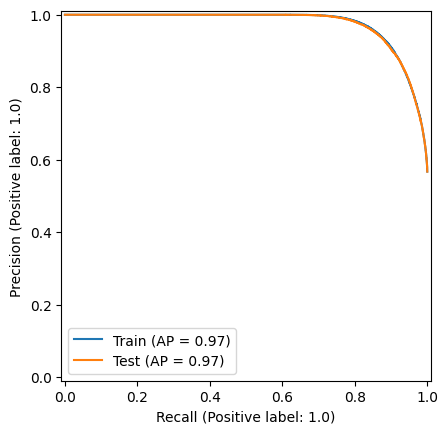

In [ ]:
# recall train vs recall test
from sklearn.metrics import recall_score
from sklearn.metrics import recall_score, PrecisionRecallDisplay

recall_train = recall_score(y_train, y_pred_train)
recall_test = recall_score(y_test, y_pred_test)

print(f"Recall Train: {recall_train:.3f}")
print(f"Recall Test : {recall_test:.3f}")
print(f"Selisih Recall (Train - Test): {abs(recall_train - recall_test):.3f}")

# menampilkan kurva Precision–Recall (PR Curve)
auc_train = PrecisionRecallDisplay.from_estimator(
  logreg_model,
  X_train,
  y_train,
  name='Train',
)

PrecisionRecallDisplay.from_estimator(
  logreg_model,
  X_test,
  y_test,
  name='Test',
  ax=auc_train.ax_,
)

#### KNN (K-Nearest Neighbors)

Pada model KNN saya memilih menggunakan data yang sudah di SMOTE dikarenakan model KNN tidak memiliki parameter class_weight, sehingga saya melakukan pendekatan teknik SMOTE untuk mengatasi ketidakseimbangan kelas.

In [ ]:
from sklearn.neighbors import KNeighborsClassifier

# Inisialisasi model KNN menggunakan data SMOTE
knn_model = KNeighborsClassifier(n_neighbors=5)

# Latih model
knn_model.fit(X_train_smote, y_train_smote)

# Cross-validation fokus pada recall
cv_scores = cross_val_score(
    knn_model,
    X_train_smote,
    y_train_smote,
    cv=5,
    scoring='recall'
)

print("=== KNN Model ===")
print(f"Cross-Validation Recall: {cv_scores.mean():.3f}")

=== KNN Model ===
Cross-Validation Recall: 0.923


In [ ]:
# Evaluasi Model Setelah Dilatih
from sklearn.metrics import classification_report, confusion_matrix

# Prediksi data train (hasil SMOTE) dan data test asli
y_pred_train = knn_model.predict(X_train_smote)
y_pred_test = knn_model.predict(X_test)

# Tampilkan confusion matrix dan classification report
print("\nConfusion Matrix (Test):")
print(confusion_matrix(y_test, y_pred_test))

print("\nClassification Report (Test):")
print(classification_report(y_test, y_pred_test))



Confusion Matrix (Test):
[[38105    62]
 [ 3761 46239]]

Classification Report (Test):
              precision    recall  f1-score   support

         0.0       0.91      1.00      0.95     38167
         1.0       1.00      0.92      0.96     50000

    accuracy                           0.96     88167
   macro avg       0.95      0.96      0.96     88167
weighted avg       0.96      0.96      0.96     88167



Recall Train (SMOTE): 0.943
Recall Test  (SMOTE): 0.925
Selisih Recall (Gap) : 0.018


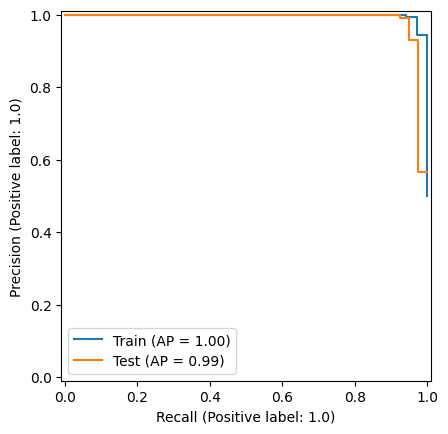

In [ ]:
# Membandingkan  Recall Train vs Recall Test
from sklearn.metrics import recall_score

# Menghitung nilai recall di data train dan test
recall_train = recall_score(y_train_smote, y_pred_train)
recall_test = recall_score(y_test, y_pred_test)

# Menghitung selisih (gap)
gap_recall = abs(recall_train - recall_test)

# Menampilkan hasil
print(f"Recall Train (SMOTE): {recall_train:.3f}")
print(f"Recall Test  (SMOTE): {recall_test:.3f}")
print(f"Selisih Recall (Gap) : {gap_recall:.3f}")

# menampilkan kurva Precision–Recall (PR Curve)
auc_train = PrecisionRecallDisplay.from_estimator(
  knn_model,
  X_train_smote,
  y_train_smote,
  name='Train',
)

PrecisionRecallDisplay.from_estimator(
  knn_model,
  X_test,
  y_test,
  name='Test',
  ax=auc_train.ax_,
)

#### Decision tree

In [ ]:
# Inisialisasi Model Decision Tree
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import cross_val_score

dt_model = DecisionTreeClassifier(
    criterion='gini',
    max_depth=None,         # None = pohon bisa tumbuh penuh
    class_weight='balanced',
    random_state=42
)

# Latih model
dt_model.fit(X_train, y_train)

# Cross-validation dengan fokus pada recall
cv_scores = cross_val_score(dt_model, X_train, y_train, cv=5, scoring='recall')
print("=== Model Decision Tree ===")
print(f"Cross-Validation Recall: {cv_scores.mean():.3f}")

=== Model Decision Tree ===
Cross-Validation Recall: 1.000


In [ ]:
# Evaluasi Model Setelah Dilatih
from sklearn.metrics import confusion_matrix, classification_report

# Prediksi data train & test
y_pred_train = dt_model.predict(X_train)
y_pred_test = dt_model.predict(X_test)

# Menampilkan confusion matrix dan classification report
print("\nConfusion Matrix (Test):")
print(confusion_matrix(y_test, y_pred_test))

print("\nClassification Report (Test):")
print(classification_report(y_test, y_pred_test))



Confusion Matrix (Test):
[[38162     5]
 [    5 49995]]

Classification Report (Test):
              precision    recall  f1-score   support

         0.0       1.00      1.00      1.00     38167
         1.0       1.00      1.00      1.00     50000

    accuracy                           1.00     88167
   macro avg       1.00      1.00      1.00     88167
weighted avg       1.00      1.00      1.00     88167



Recall Train: 1.000
Recall Test : 1.000
Selisih Recall (Gap): 0.000


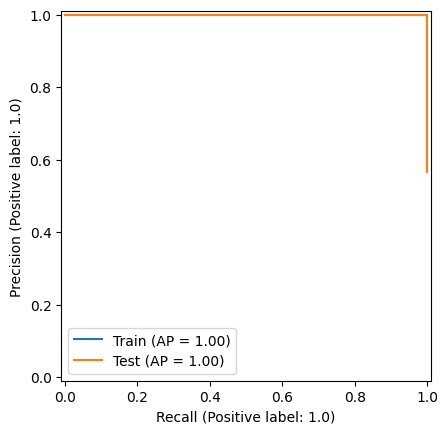

In [ ]:
# Membandingkan Recall Train vs Recall Test
from sklearn.metrics import recall_score

# Menghitung recall untuk train dan test
recall_train = recall_score(y_train, y_pred_train)
recall_test = recall_score(y_test, y_pred_test)
gap_recall = abs(recall_train - recall_test)

# Menampilkan hasil perbandingan
print(f"Recall Train: {recall_train:.3f}")
print(f"Recall Test : {recall_test:.3f}")
print(f"Selisih Recall (Gap): {gap_recall:.3f}")

# menampilkan kurva Precision–Recall (PR Curve)
auc_train = PrecisionRecallDisplay.from_estimator(
  dt_model,
  X_train,
  y_train,
  name='Train',
)

PrecisionRecallDisplay.from_estimator(
  dt_model,
  X_test,
  y_test,
  name='Test',
  ax=auc_train.ax_,
)

#### SVM RBF

In [ ]:
from sklearn.svm import LinearSVC

svm_linear = LinearSVC(
    class_weight='balanced',
    random_state=42,
    max_iter=5000
)
svm_linear.fit(X_train, y_train)

# Latih model
svm_linear.fit(X_train, y_train)

# Cross-validation dengan fokus pada recall
cv_scores = cross_val_score(svm_linear, X_train, y_train, cv=5, scoring='recall')
print("=== Model SVM RBF ===")
print(f"Cross-Validation Recall: {cv_scores.mean():.3f}")

=== Model SVM RBF ===
Cross-Validation Recall: 0.868


In [ ]:
# Evaluasi Model LinearSVC
from sklearn.metrics import confusion_matrix, classification_report

# Prediksi data train & test
y_pred_train = svm_linear.predict(X_train)
y_pred_test = svm_linear.predict(X_test)

# Menampilkan confusion matrix dan classification report
print("\nConfusion Matrix (Test):")
print(confusion_matrix(y_test, y_pred_test))

print("\nClassification Report (Test):")
print(classification_report(y_test, y_pred_test))



Confusion Matrix (Test):
[[35521  2646]
 [ 6655 43345]]

Classification Report (Test):
              precision    recall  f1-score   support

         0.0       0.84      0.93      0.88     38167
         1.0       0.94      0.87      0.90     50000

    accuracy                           0.89     88167
   macro avg       0.89      0.90      0.89     88167
weighted avg       0.90      0.89      0.89     88167



Recall Train: 0.868
Recall Test : 0.867
Selisih Recall (Gap): 0.002


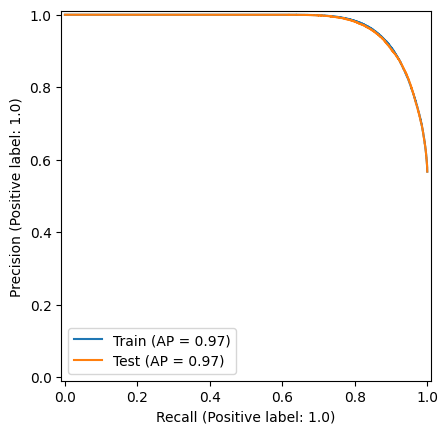

In [ ]:
# Membandingkan Recall Train vs Recall Test
from sklearn.metrics import recall_score, PrecisionRecallDisplay

# Menghitung recall untuk train dan test
recall_train = recall_score(y_train, y_pred_train)
recall_test = recall_score(y_test, y_pred_test)
gap_recall = abs(recall_train - recall_test)

# Menampilkan hasil perbandingan
print(f"Recall Train: {recall_train:.3f}")
print(f"Recall Test : {recall_test:.3f}")
print(f"Selisih Recall (Gap): {gap_recall:.3f}")

#  Menampilkan Kurva Precision–Recall (PR Curve)
auc_train = PrecisionRecallDisplay.from_estimator(
    svm_linear,
    X_train,
    y_train,
    name='Train',
)

PrecisionRecallDisplay.from_estimator(
    svm_linear,
    X_test,
    y_test,
    name='Test',
    ax=auc_train.ax_,
)


Hasil Setiap Model:

1. Logistic Regression:
- Model ini cukup baik dalam mengidentifikasi pelanggan yang akan churn.
- Nilai Recall pada data latihan dan data uji sangat mirip (sekitar 0.87), yang berarti model konsisten dan tidak terlalu "menghafal" data latihan.

2. KNN (K-Nearest Neighbors):
- Model menunjukkan Recall yang lebih tinggi (sekitar 0.925) pada data uji dibandingkan Logistic Regression.
- Yang berarti KNN lebih baik dalam menemukan pelanggan yang berisiko churn.
- Perbedaan Recall antara data latihan (setelah SMOTE) dan data uji sedikit lebih besar (0.018) dibandingkan Logistic Regression,  masih dalam batas wajar dan menunjukkan kinerja yang baik.
3. Decision Tree:
- Model menunjukkan Recall yang sempurna (1.000) baik di data latihan maupun data uji.
- terlihat model berhasil mengidentifikasi semua pelanggan yang akan churn di data uji.
- Selisih Recall antara data latihan dan data uji adalah 0.000, yang menunjukkan konsistensi yang luar biasa.
4. SVM RBF (Support Vector Machine dengan kernel RBF):
- Model memiliki kinerja Recall yang mirip dengan Logistic Regression (sekitar 0.867) pada data uji.
- Model juga cukup konsisten dengan selisih Recall yang kecil antara data latihan dan data uji.

Model Terbaik Berdasarkan Recall:
- Berdasarkan hasil evaluasi empat model machine learning yang digunakan, yaitu Logistic Regression, K-Nearest Neighbors (KNN), Decision Tree, dan Support Vector Machine (SVM) dengan kernel RBF, seluruh model menunjukkan performa yang baik dalam mengidentifikasi pelanggan yang berpotensi churn. Fokus utama evaluasi diarahkan pada metrik recall, karena tujuan analisis adalah untuk meminimalkan kesalahan dalam mendeteksi pelanggan yang benar-benar akan churn.

- Dari hasil menunjukkan bahwa Decision Tree memiliki nilai recall tertinggi baik pada data train maupun test, yaitu 1.000, dengan selisih recall (gap) sebesar 0.000, menandakan model ini sangat konsisten dan tidak mengalami overfitting terhadap data. Sementara itu, KNN juga menunjukkan performa yang cukup baik dengan recall test sebesar 0.925, sedangkan Logistic Regression dan SVM RBF menunjukkan hasil recall yang stabil dengan nilai sekitar 0.87 dan gap yang sangat kecil.

- Jai model Decision Tree dapat dikatakan sebagai model terbaik dalam konteks analisis yang telah dilakukan, karena mampu memberikan hasil recall sempurna tanpa perbedaan antara data pelatihan dan pengujian.

### Assignment Profitable :
1. Lakukan perhitungan profitable dengan asumsi biaya yang anda buat sendiri.

#### Define Assumptions

In [ ]:
# Asumsi biaya
# Biaya untuk mempertahankan satu pelanggan yang berpotensi churn (misalnya, biaya penawaran diskon, program loyalitas, dll.)
cost_of_retention = 50

# Estimasi pendapatan yang hilang jika satu pelanggan churn (misalnya, rata-rata lifetime value pelanggan)
revenue_loss_from_churn = 500

print(f"Asumsi Biaya Retensi per Pelanggan: ${cost_of_retention}")
print(f"Asumsi Pendapatan Hilang per Pelanggan Churn: ${revenue_loss_from_churn}")

Asumsi Biaya Retensi per Pelanggan: $50
Asumsi Pendapatan Hilang per Pelanggan Churn: $500


#### Calculate Costs and Benefits

In [ ]:
# Mengambil confusion matrix dari model Decision Tree (dari output sebelumnya)
# [[TN, FP],
#  [FN, TP]]
# [[38162     5]
#  [    5 49995]]

tn, fp, fn, tp = 38162, 5, 5, 49995

print(f"True Negatives (TN): {tn}") # Pelanggan tidak churn dan diprediksi tidak churn
print(f"False Positives (FP): {fp}") # Pelanggan tidak churn tapi diprediksi churn (biaya retensi yang tidak perlu)
print(f"False Negatives (FN): {fn}") # Pelanggan churn tapi diprediksi tidak churn (pendapatan yang hilang)
print(f"True Positives (TP): {tp}") # Pelanggan churn dan diprediksi churn (berhasil diidentifikasi untuk intervensi)

True Negatives (TN): 38162
False Positives (FP): 5
False Negatives (FN): 5
True Positives (TP): 49995


In [ ]:
# Total biaya yang dikeluarkan untuk intervensi retensi
# Termasuk False Positives (biaya untuk mempertahankan pelanggan yang sebenarnya tidak akan churn)
# True Positives (biaya untuk mempertahankan pelanggan yang berpotensi churn dan berhasil diidentifikasi)
total_retention_cost = (fp + tp) * cost_of_retention

# Total pendapatan yang berhasil diselamatkan
# Pendapatan yang tidak hilang karena berhasil mempertahankan True Positives
total_revenue_saved = tp * revenue_loss_from_churn

# Total pendapatan yang hilang (karena False Negatives)
# Pendapatan yang hilang dari pelanggan yang churn tetapi tidak teridentifikasi oleh model
total_revenue_lost_from_fn = fn * revenue_loss_from_churn


print(f"Total Biaya Retensi: ${total_retention_cost}")
print(f"Total Pendapatan yang Diselamatkan: ${total_revenue_saved}")
print(f"Total Pendapatan yang Hilang (dari FN): ${total_revenue_lost_from_fn}")

Total Biaya Retensi: $2500000
Total Pendapatan yang Diselamatkan: $24997500
Total Pendapatan yang Hilang (dari FN): $2500


#### Calculate Profitability

In [ ]:
# Hitung profitabilitas bersih
# Total pendapatan yang diselamatkan dikurangi total biaya yang dikeluarkan
net_profitability = total_revenue_saved - total_retention_cost - total_revenue_lost_from_fn

print(f"Profitabilitas Bersih dari Model Churn: ${net_profitability}")

Profitabilitas Bersih dari Model Churn: $22495000


#### Summarize Findings

Berdasarkan perhitungan yang telah dilakukan dengan asumsi biaya retensi sebesar 50 dolar {cost_of_retention} per pelanggan dan potensi pendapatan hilang sebesar 500 dolar {revenue_loss_from_churn} per pelanggan churn, model churn yang dibangun menunjukkan profitabilitas bersih sebesar **22495000 dolar{net_profitability}**.

Dengan mengidentifikasi dan melakukan intervensi retensi pada pelanggan yang diprediksi akan churn, perusahaan berpotensi mendapatkan keuntungan sebesar 22495000 dolar dibandingkan jika tidak melakukan intervensi sama sekali.
